In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

ПУНКТ а)

In [24]:
# Данные
X = np.array([[1, 0],
              [0, 1],
              [1, 1]])

Y = np.array([1, 5, 2])

# построение модели
beta_ols = np.linalg.inv(X.T @ X) @ (X.T @ Y)

print("модель регресии:")
print(f"ω = {beta_ols[0]:.4f}·ξ + {beta_ols[1]:.4f}·η")

модель регресии:
ω = -0.3333·ξ + 3.6667·η


ПУНКТ b)

Ridge регрессия (ручной CV)
Оптимальное λ = 1.5024
ω = 0.3113·ξ + 1.9098·η


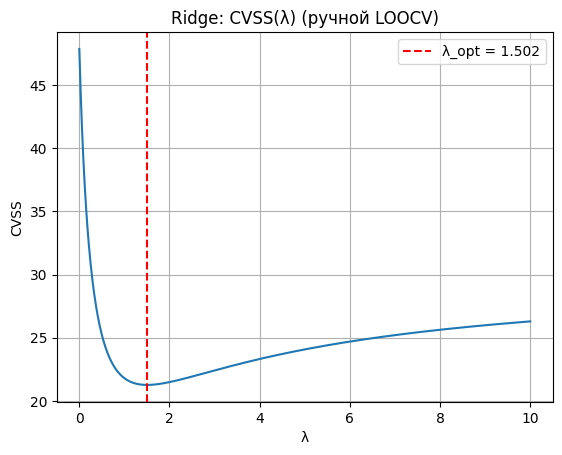

In [25]:
def cvss_ridge(alpha):
    ss = 0
    for i in range(3):
        # Обучающая выборка без i-й точки
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y, i)
        
        # Ridge на обучающей выборке
        ridge = Ridge(alpha=alpha, fit_intercept=False, max_iter=10000)
        ridge.fit(X_train, Y_train)
        
        # Ошибка на отложенной точке
        pred = X[i] @ ridge.coef_
        ss += (Y[i] - pred) ** 2
    return ss

# Перебираем λ
lambd = np.linspace(0.001, 10, 1000)
cvss_values = [cvss_ridge(a) for a in lambd]

# Оптимальное λ
best_idx = np.argmin(cvss_values)
lambd_opt = lambd[best_idx]

# Коэффициенты при оптимальном λ
ridge_opt = Ridge(alpha=lambd_opt, fit_intercept=False, max_iter=10000)
ridge_opt.fit(X, Y)

print("Ridge регрессия (ручной CV)")
print(f"Оптимальное λ = {lambd_opt:.4f}")
print(f"ω = {ridge_opt.coef_[0]:.4f}·ξ + {ridge_opt.coef_[1]:.4f}·η")

# График
plt.plot(lambd, cvss_values)
plt.axvline(lambd_opt, color='r', linestyle='--', label=f'λ_opt = {lambd_opt:.3f}')
plt.xlabel('λ')
plt.ylabel('CVSS')
plt.title('Ridge: CVSS(λ) (ручной LOOCV)')
plt.legend()
plt.grid(True)
plt.show()

ПУНКТ c)

Lasso регрессия
Оптимальное λ = 1.5024
ω = 0.0000·ξ + 1.2465·η


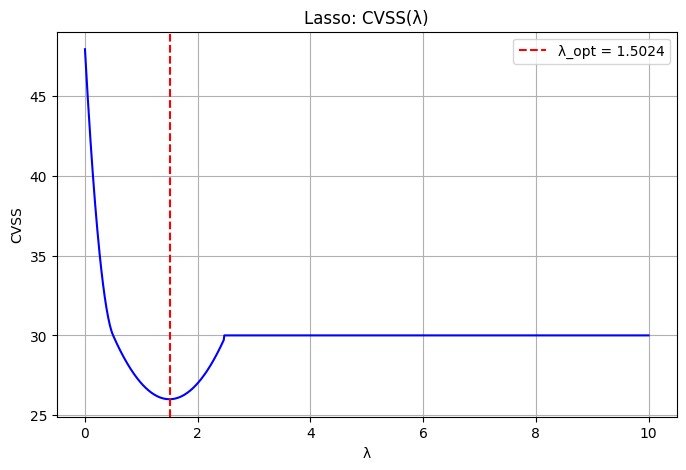

In [26]:
# Leave-One-Out CV для Lasso
def cvss_lasso(alpha):
    ss = 0
    for i in range(3):
        # Обучающая выборка без i-й точки
        X_train = np.delete(X, i, axis=0)
        Y_train = np.delete(Y, i)
        
        # Lasso на обучающей выборке
        lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
        lasso.fit(X_train, Y_train)
        
        # Ошибка на отложенной точке
        pred = X[i] @ lasso.coef_
        ss += (Y[i] - pred) ** 2
    return ss

# Перебираем λ
lambd = np.linspace(0.001, 10, 1000)
cvss_values = [cvss_lasso(a) for a in lambd]

# Оптимальное λ
best_idx = np.argmin(cvss_values)
lambd_opt = lambd[best_idx]

# Коэффициенты при оптимальном λ
lasso_opt = Lasso(alpha=lambd_opt, fit_intercept=False, max_iter=10000)
lasso_opt.fit(X, Y)

print("Lasso регрессия")
print(f"Оптимальное λ = {lambd_opt:.4f}")
print(f"ω = {lasso_opt.coef_[0]:.4f}·ξ + {lasso_opt.coef_[1]:.4f}·η")

# График CVSS
plt.figure(figsize=(8, 5))
plt.plot(lambd, cvss_values, 'b-', linewidth=1.5)
plt.axvline(lambd_opt, color='red', linestyle='--', label=f'λ_opt = {lambd_opt:.4f}')
plt.xlabel('λ')
plt.ylabel('CVSS')
plt.title('Lasso: CVSS(λ)')
plt.legend()
plt.grid(True)
plt.show()